#  Business Insights & Recommendations

This notebook summarizes the key findings from the exploratory data analysis and provides actionable business recommendations based on the data.

##  Objective

The goal of this analysis is to transform raw transactional data into meaningful insights that can support business decision-making and improve overall performance.

##  Load Key Data

We load key aggregated datasets generated during the exploratory analysis phase.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Load datasets
df = pd.read_csv('data/online_retail_cleaned.csv', parse_dates=['InvoiceDate'])
customer_stats = pd.read_csv('data/customer_stats.csv')
order_stats = pd.read_csv('data/order_stats.csv')

print("✓ Data loaded successfully")

✓ Data loaded successfully


##  Key Insight 1: Sales Trends

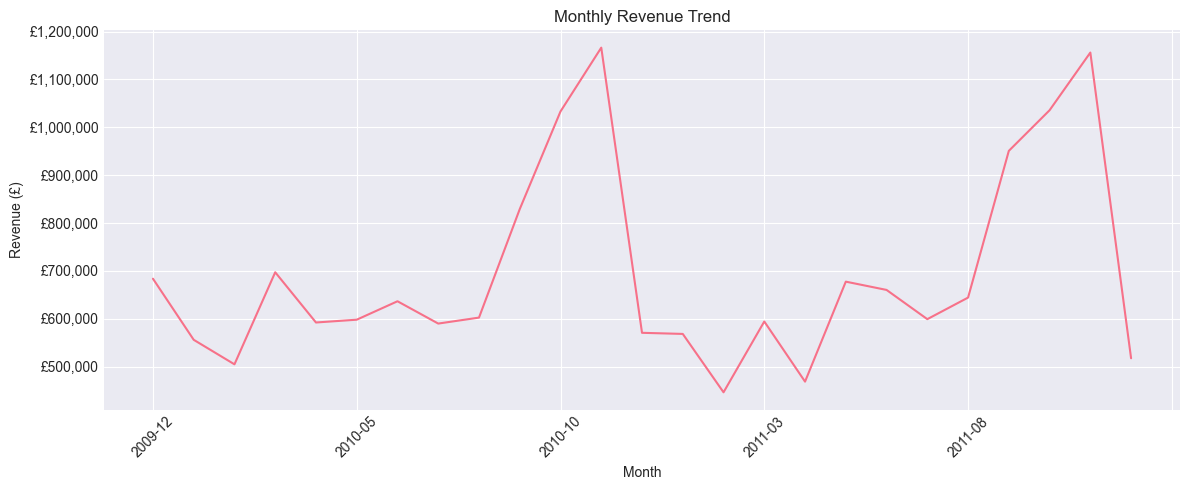

In [2]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)

monthly_revenue = df.groupby('YearMonth')['TotalPrice'].sum()

plt.figure(figsize=(12, 5))
monthly_revenue.plot()
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.show()

### Insight

Revenue varies significantly across months, indicating strong seasonality in customer purchasing behavior. Certain periods generate much higher sales, suggesting opportunities for targeted marketing campaigns.

##  Key Insight 2: Product Performance

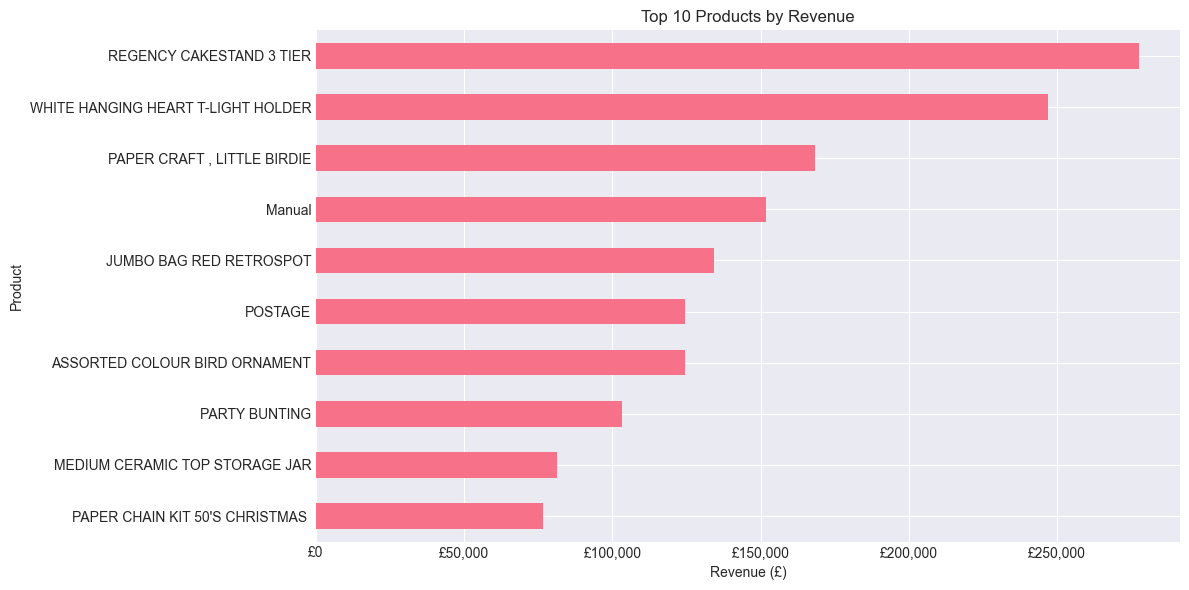

Description
REGENCY CAKESTAND 3 TIER              277656.25
WHITE HANGING HEART T-LIGHT HOLDER    247048.01
PAPER CRAFT , LITTLE BIRDIE           168469.60
Manual                                151777.67
JUMBO BAG RED RETROSPOT               134307.44
POSTAGE                               124648.04
ASSORTED COLOUR BIRD ORNAMENT         124351.86
PARTY BUNTING                         103283.38
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         76598.18
Name: TotalPrice, dtype: float64

In [3]:
top_products = (
    df.groupby('Description')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
top_products.sort_values().plot(kind='barh')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('Product')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.show()

top_products

### Insight

A small number of products generate a large share of total revenue. This indicates a strong concentration of sales around key items, which should be prioritized in marketing and inventory strategies.

## 👥 Key Insight 3: Customer Value Distribution

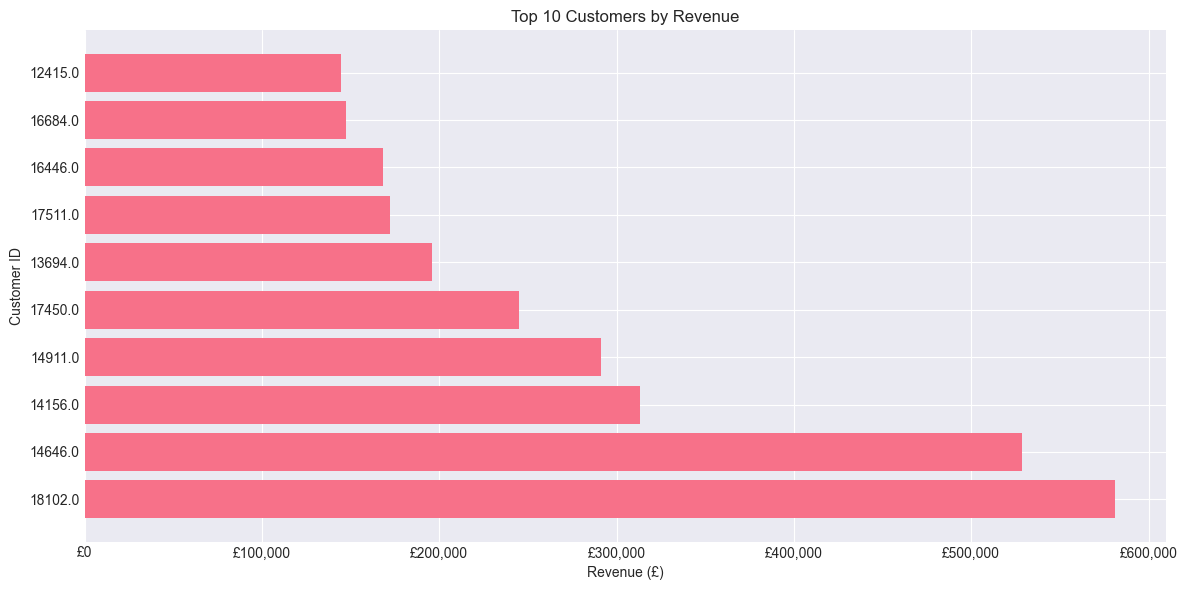

,Customer ID,Total_Revenue,Total_Orders
5692,18102.0,580987.04,145
2277,14646.0,528602.52,151
1789,14156.0,313437.62,156
2538,14911.0,291420.81,398
5050,17450.0,244784.25,51
1331,13694.0,195640.69,143
5109,17511.0,172132.87,60
4061,16446.0,168472.50,2
4295,16684.0,147142.77,55
68,12415.0,144458.37,28


In [4]:
top_customers = customer_stats.sort_values(by='Total_Revenue', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_customers['Customer ID'].astype(str), top_customers['Total_Revenue'])
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('Customer ID')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.show()

top_customers[['Customer ID', 'Total_Revenue', 'Total_Orders']]

### Insight

Customer spending is highly uneven, with a small group of customers contributing a large portion of total revenue. This highlights the importance of retaining high-value customers.

## 🌍 Key Insight 4: Geographic Distribution

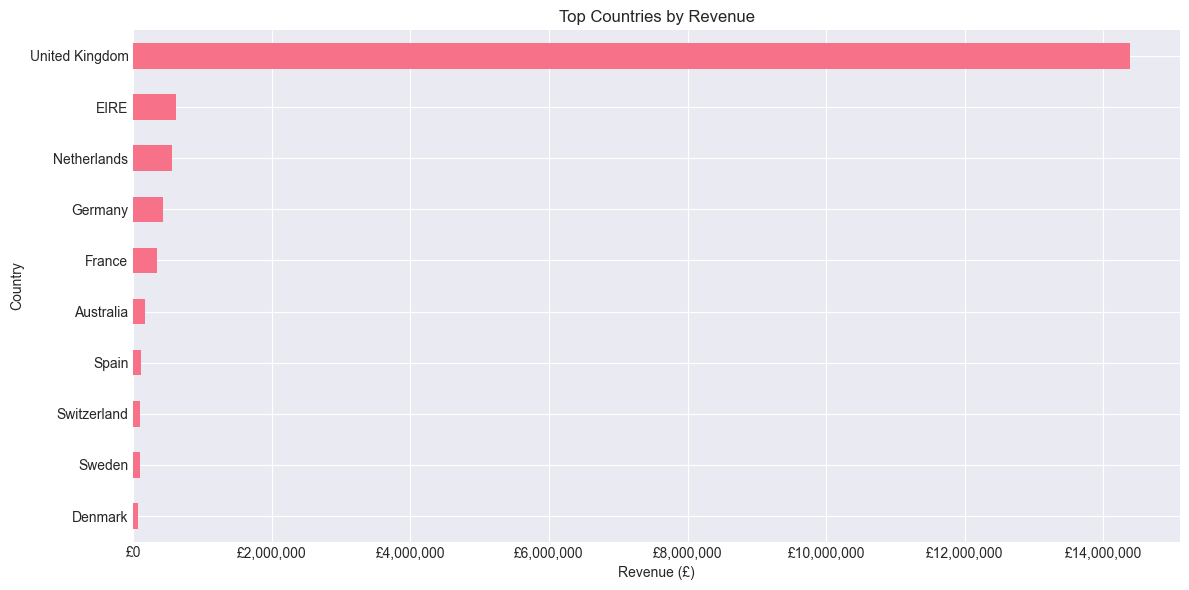

Country
United Kingdom    1.438923e+07
EIRE              6.165705e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.487690e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.000619e+05
Sweden            9.151582e+04
Denmark           6.858069e+04
Name: TotalPrice, dtype: float64

In [5]:
country_revenue = (
    df.groupby('Country')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
country_revenue.sort_values().plot(kind='barh')
plt.title('Top Countries by Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('Country')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.show()

country_revenue

### Insight

The United Kingdom dominates total revenue, while other countries contribute smaller shares. This suggests potential opportunities for expanding international sales.

##  Business Recommendations

### 1. Focus on High-Value Customers
- Develop loyalty programs to retain top customers
- Offer personalized promotions and discounts

### 2. Optimize Product Strategy
- Promote high-performing products
- Bundle popular items to increase average order value

### 3. Leverage Seasonality
- Increase marketing efforts during peak months
- Plan inventory based on seasonal demand patterns

### 4. Expand International Presence
- Target underperforming markets
- Adapt strategies to regional preferences

### 5. Increase Order Value
- Encourage bulk purchases
- Use cross-selling and upselling techniques

## ⚠️ Limitations

- The dataset represents historical transactions and may not reflect current trends
- Missing customer information may impact analysis accuracy
- External factors such as marketing campaigns are not included

## ✅ Conclusion

This project demonstrates a complete data analysis workflow, from data cleaning to exploratory analysis and business insight generation. The findings provide valuable understanding of customer behavior, product performance, and sales trends, supporting data-driven decision-making.